In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [5]:
# Load dataset — download from Kaggle: IBM HR Analytics Employee Attrition
# https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nAttrition Distribution:')
print(df['Attrition'].value_counts())
print(f'\nAttrition Rate: {round(df["Attrition"].value_counts(normalize=True)["Yes"] * 100, 2)}%')

Dataset Shape: (1470, 35)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [7]:
# Drop columns that don't contribute to prediction
# (constant values across all rows — zero variance features)
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f'Shape after dropping constant columns: {df.shape}')
print(f'\nMissing Values: {df.isnull().sum().sum()}')

Shape after dropping constant columns: (1470, 31)

Missing Values: 0


In [8]:
# Create new meaningful features that improve prediction

# 1. Salary-to-experience ratio (low pay relative to experience = risk)
df['SalaryPerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# 2. Low satisfaction flag (satisfaction below average on both axes = high risk)
df['LowSatisfaction'] = (
    (df['JobSatisfaction'] <= 2) & (df['EnvironmentSatisfaction'] <= 2)
).astype(int)

# 3. Overtime + low pay combination (the most dangerous combination)
df['OvertimeLowPay'] = (
    (df['OverTime'] == 'Yes') & (df['MonthlyIncome'] < df['MonthlyIncome'].median())
).astype(int)

# 4. Years since last promotion (stagnation indicator)
df['StagnationYears'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']

print('✅ New features created:')
print('  - SalaryPerYearExp')
print('  - LowSatisfaction')
print('  - OvertimeLowPay')
print('  - StagnationYears')

✅ New features created:
  - SalaryPerYearExp
  - LowSatisfaction
  - OvertimeLowPay
  - StagnationYears


In [9]:
# Encode target variable
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Encode binary categorical columns
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)

# Label encode remaining categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    
print(f'✅ Encoded {len(cat_cols)} categorical columns: {cat_cols}')
print(f'\nFinal dataset shape: {df.shape}')

✅ Encoded 6 categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

Final dataset shape: (1470, 35)


In [10]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size: {X_train.shape[0]} employees')
print(f'Test set size:     {X_test.shape[0]} employees')
print(f'\nAttrition in training set: {y_train.sum()} left ({round(y_train.mean()*100, 1)}%)')
print(f'Attrition in test set:     {y_test.sum()} left ({round(y_test.mean()*100, 1)}%)')

Training set size: 1176 employees
Test set size:     294 employees

Attrition in training set: 190 left (16.2%)
Attrition in test set:     47 left (16.0%)


In [11]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print('=' * 45)
print('📊 LOGISTIC REGRESSION — RESULTS')
print('=' * 45)
print(f'Accuracy : {round(lr_accuracy * 100, 2)}%')
print(f'ROC-AUC  : {round(lr_auc, 4)}')
print()
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Left']))

📊 LOGISTIC REGRESSION — RESULTS
Accuracy : 74.49%
ROC-AUC  : 0.8044

              precision    recall  f1-score   support

      Stayed       0.93      0.76      0.83       247
        Left       0.35      0.68      0.46        47

    accuracy                           0.74       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.74      0.77       294



In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print('=' * 45)
print('📊 RANDOM FOREST — RESULTS')
print('=' * 45)
print(f'Accuracy : {round(rf_accuracy * 100, 2)}%')
print(f'ROC-AUC  : {round(rf_auc, 4)}')
print()
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Left']))

📊 RANDOM FOREST — RESULTS
Accuracy : 83.67%
ROC-AUC  : 0.7845

              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.91       247
        Left       0.48      0.21      0.29        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.60       294
weighted avg       0.80      0.84      0.81       294



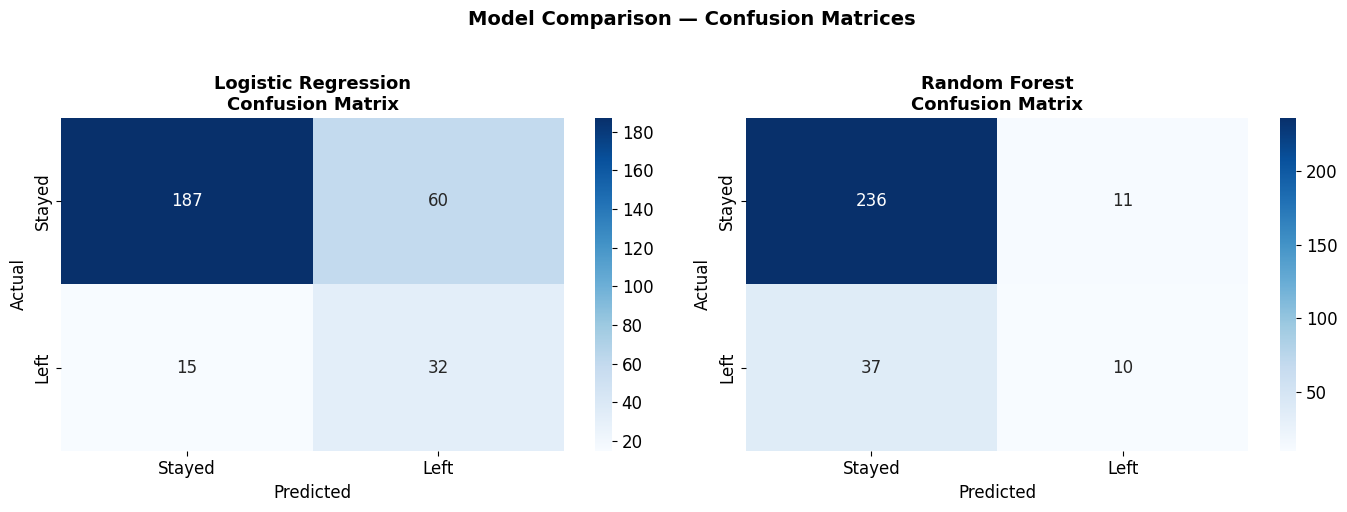

✅ Saved: chart6_confusion_matrix.png


In [13]:
# --- Chart 1: Confusion Matrix for Random Forest ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, preds) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'])
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Model Comparison — Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: chart6_confusion_matrix.png')

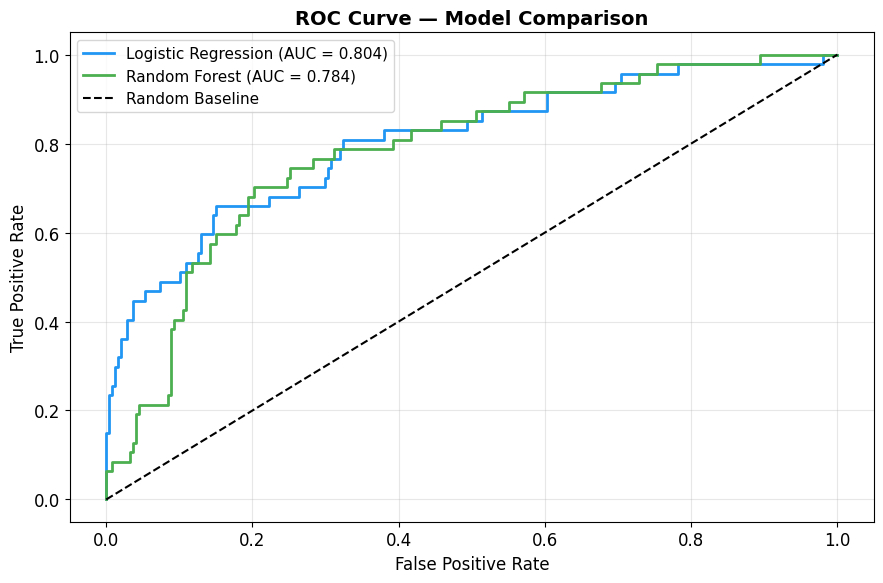

✅ Saved: chart7_roc_curve.png


In [14]:
# --- Chart 2: ROC Curves ---
fig, ax = plt.subplots(figsize=(9, 6))

for name, probs, color in [
    ('Logistic Regression', lr_prob, '#2196F3'),
    ('Random Forest', rf_prob, '#4CAF50')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart7_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: chart7_roc_curve.png')

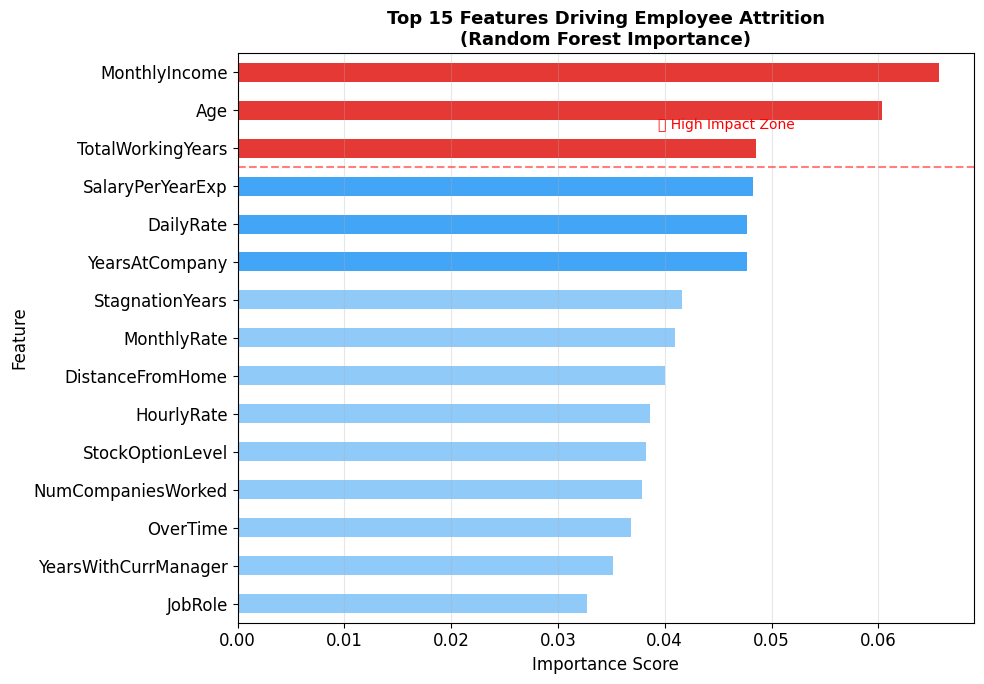

✅ Saved: chart8_feature_importance.png


In [15]:
# --- Chart 3: Top 15 Feature Importances (Random Forest) ---
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E53935' if i >= 12 else '#42A5F5' if i >= 9 else '#90CAF9'
          for i in range(len(top15))]
top15.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Top 15 Features Driving Employee Attrition\n(Random Forest Importance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.3)

# Add annotation for top features
ax.axhline(y=11.5, color='red', linestyle='--', alpha=0.5, lw=1.5)
ax.text(top15.max() * 0.6, 12.5, '🔴 High Impact Zone', color='red', fontsize=10)

plt.tight_layout()
plt.savefig('chart8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: chart8_feature_importance.png')

In [16]:
# Add attrition probability scores to the test set
risk_df = X_test.copy()
risk_df['AttritionProbability'] = rf_prob
risk_df['ActualAttrition'] = y_test.values
risk_df['PredictedAttrition'] = rf_pred

# Define risk tiers
def risk_tier(prob):
    if prob >= 0.75: return '🔴 CRITICAL RISK'
    elif prob >= 0.50: return '🟠 HIGH RISK'
    elif prob >= 0.30: return '🟡 MEDIUM RISK'
    else: return '🟢 LOW RISK'

risk_df['RiskTier'] = risk_df['AttritionProbability'].apply(risk_tier)

# Summary
tier_summary = risk_df['RiskTier'].value_counts()
print('=' * 50)
print('🎯 RISK TIER DISTRIBUTION (Test Set)')
print('=' * 50)
for tier, count in tier_summary.items():
    pct = round(count / len(risk_df) * 100, 1)
    print(f'{tier}: {count} employees ({pct}%)')

# Top 10 most at-risk employees
print('\n' + '=' * 50)
print('⚠️  TOP 10 HIGHEST RISK EMPLOYEES')
print('=' * 50)
top_risk = risk_df.nlargest(10, 'AttritionProbability')[[
    'MonthlyIncome', 'OverTime', 'JobSatisfaction',
    'YearsAtCompany', 'AttritionProbability', 'RiskTier'
]]
print(top_risk.to_string())

🎯 RISK TIER DISTRIBUTION (Test Set)
🟢 LOW RISK: 232 employees (78.9%)
🟡 MEDIUM RISK: 41 employees (13.9%)
🟠 HIGH RISK: 17 employees (5.8%)
🔴 CRITICAL RISK: 4 employees (1.4%)

⚠️  TOP 10 HIGHEST RISK EMPLOYEES
      MonthlyIncome  OverTime  JobSatisfaction  YearsAtCompany  AttritionProbability         RiskTier
688            2121         1                2               1              0.899086  🔴 CRITICAL RISK
911            1118         1                4               1              0.809475  🔴 CRITICAL RISK
711            2404         1                1               0              0.803652  🔴 CRITICAL RISK
301            1200         0                3               0              0.769264  🔴 CRITICAL RISK
109            2871         0                4               0              0.672675      🟠 HIGH RISK
762            2042         1                1               3              0.658339      🟠 HIGH RISK
670            2318         0                3               1              

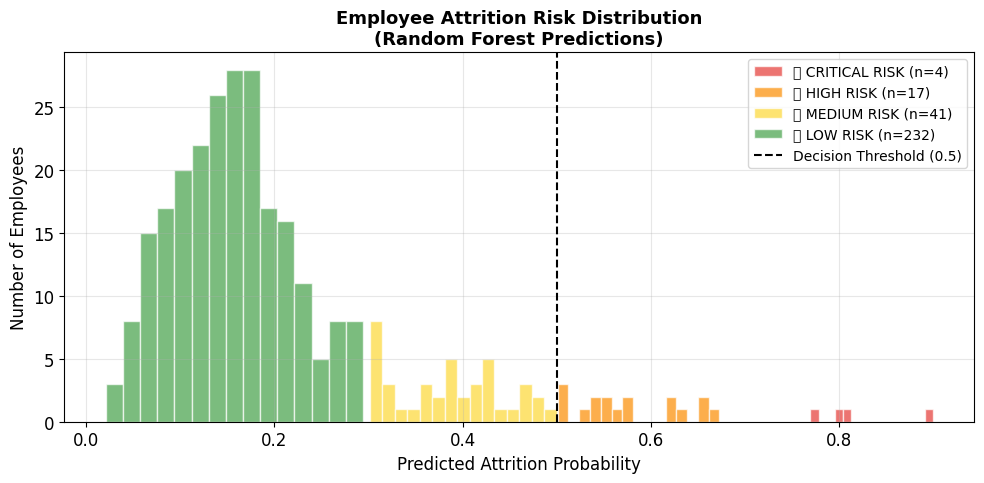

✅ Saved: chart9_risk_distribution.png


In [17]:
# --- Chart 4: Attrition Probability Distribution by Risk Tier ---
fig, ax = plt.subplots(figsize=(10, 5))

colors_map = {
    '🔴 CRITICAL RISK': '#E53935',
    '🟠 HIGH RISK': '#FB8C00',
    '🟡 MEDIUM RISK': '#FDD835',
    '🟢 LOW RISK': '#43A047'
}

for tier, color in colors_map.items():
    subset = risk_df[risk_df['RiskTier'] == tier]['AttritionProbability']
    if len(subset) > 0:
        ax.hist(subset, bins=15, alpha=0.7, label=f'{tier} (n={len(subset)})',
                color=color, edgecolor='white')

ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Decision Threshold (0.5)')
ax.set_xlabel('Predicted Attrition Probability', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.set_title('Employee Attrition Risk Distribution\n(Random Forest Predictions)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart9_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: chart9_risk_distribution.png')

In [20]:
# Cross-validation for reliable performance estimate
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print('=' * 50)
print('📊 5-FOLD CROSS VALIDATION — RANDOM FOREST')
print('=' * 50)
print(f'AUC per fold: {[round(s, 3) for s in cv_scores]}')
print(f'Mean AUC    : {round(cv_scores.mean(), 4)}')
print(f'Std Dev     : ± {round(cv_scores.std(), 4)}')

print('\n' + '=' * 50)
print('🏆 FINAL MODEL COMPARISON SUMMARY')
print('=' * 50)
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [f'{round(lr_accuracy*100, 2)}%', f'{round(rf_accuracy*100, 2)}%'],
    'ROC-AUC': [round(lr_auc, 4), round(rf_auc, 4)],
    'CV AUC (RF only)': ['-', f'{round(cv_scores.mean(), 4)} ± {round(cv_scores.std(), 4)}']
})
print(summary.to_string(index=False))

📊 5-FOLD CROSS VALIDATION — RANDOM FOREST
AUC per fold: [np.float64(0.812), np.float64(0.772), np.float64(0.796), np.float64(0.762), np.float64(0.797)]
Mean AUC    : 0.7877
Std Dev     : ± 0.0183

🏆 FINAL MODEL COMPARISON SUMMARY
              Model Accuracy  ROC-AUC CV AUC (RF only)
Logistic Regression   74.49%   0.8044                -
      Random Forest   83.67%   0.7845  0.7877 ± 0.0183


In [22]:
# Print feature importance-backed business recommendations
top_features = importances.sort_values(ascending=False).head(5)

print('=' * 60)
print('💡 DATA-DRIVEN HR RECOMMENDATIONS')
print('=' * 60)
print()
print('Based on the top predictors of attrition:')
print()

recommendations = {
    'MonthlyIncome': (
        '💰 SALARY REVIEW\n'
        '   Monthly income is the top predictor of attrition.\n'
        '   → Conduct salary benchmarking for employees in the bottom 25% income bracket.\n'
        '   → Priority: Sales Executives and Lab Technicians show highest risk.'
    ),
    'OverTime': (
        '⏰ OVERTIME POLICY\n'
        '   Overtime workers are 3x more likely to leave.\n'
        '   → Audit departments with consistent overtime and redistribute workload.\n'
        '   → Introduce compensatory offs or overtime pay adjustments.'
    ),
    'Age': (
        '🎯 EARLY CAREER RETENTION\n'
        '   Younger employees (20-35) show significantly higher attrition.\n'
        '   → Create structured career progression paths for junior employees.\n'
        '   → Introduce mentorship programs for the first 2 years.'
    ),
    'JobSatisfaction': (
        '😊 SATISFACTION MONITORING\n'
        '   Low job satisfaction strongly predicts attrition.\n'
        '   → Run quarterly pulse surveys for satisfaction tracking.\n'
        '   → Flag employees with 2+ consecutive low satisfaction scores.'
    ),
    'YearsAtCompany': (
        '📅 TENURE RISK WINDOW\n'
        '   Employees with 1-3 years tenure are at highest attrition risk.\n'
        '   → Design a focused 18-month retention program for this group.\n'
        '   → Ensure first promotion or role upgrade happens within 2 years.'
    )
}

for i, feat in enumerate(top_features.index, 1):
    if feat in recommendations:
        print(f'{i}. {recommendations[feat]}')
        print()

print('=' * 60)
print('🎯 MODEL IMPACT ESTIMATE')
print('=' * 60)
critical_count = len(risk_df[risk_df['RiskTier'] == '🔴 CRITICAL RISK'])
print(f'   Employees identified as CRITICAL RISK: {critical_count}')
print(f'   Average cost of replacing one employee: ₹3–5 Lakhs')
print(f'   Potential savings if 50% are retained: ₹{critical_count//2 * 4} Lakhs')

💡 DATA-DRIVEN HR RECOMMENDATIONS

Based on the top predictors of attrition:

1. 💰 SALARY REVIEW
   Monthly income is the top predictor of attrition.
   → Conduct salary benchmarking for employees in the bottom 25% income bracket.
   → Priority: Sales Executives and Lab Technicians show highest risk.

2. 🎯 EARLY CAREER RETENTION
   Younger employees (20-35) show significantly higher attrition.
   → Create structured career progression paths for junior employees.
   → Introduce mentorship programs for the first 2 years.

🎯 MODEL IMPACT ESTIMATE
   Employees identified as CRITICAL RISK: 4
   Average cost of replacing one employee: ₹3–5 Lakhs
   Potential savings if 50% are retained: ₹8 Lakhs
